**1. IMPORT DEPENDENCIES AND DATA**

In [1]:
!pip install tensorflow matplotlib tensorflow-datasets ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.9 MB/s eta 0:00:00


In [2]:
!pip list

Package                            Version
---------------------------------- -------------------
absl-py                            1.4.0
accelerate                         1.2.1
aiohappyeyeballs                   2.4.4
aiohttp                            3.11.11
aiosignal                          1.3.2
alabaster                          1.0.0
albucore                           0.0.19
albumentations                     1.4.20
ale-py                             0.10.1
altair                             5.5.0
annotated-types                    0.7.0
anyio                              3.7.1
argon2-cffi                        23.1.0
argon2-cffi-bindings               21.2.0
array_record                       0.6.0
arviz                              0.20.0
astropy                            6.1.7
astropy-iers-data                  0.2025.1.27.0.32.44
astunparse                         1.6.3
atpublic                           4.1.0
attrs                              25.1.0
audioread         

In [3]:
#importing tensorflow
import tensorflow as tf
gpuss = tf.config.list_physical_devices('GPU')
for gpu in gpuss:
  tf.config.experimental.set_memory_growth(gpu, True)

In [4]:
gpuss

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt


In [6]:
ds = tfds.load('fashion_mnist', split='train')

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/60000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.576UJ4_3.0.1/fashion_mnist-train.tfrecord*...:   …

Generating test examples...:   0%|          | 0/10000 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/fashion_mnist/incomplete.576UJ4_3.0.1/fashion_mnist-test.tfrecord*...:   0…

Dataset fashion_mnist downloaded and prepared to /root/tensorflow_datasets/fashion_mnist/3.0.1. Subsequent calls will reuse this data.


In [7]:
type(ds)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [8]:
#This line retrieves the next batch or element from the TensorFlow dataset ds and ensures that the data is in NumPy array format.
ds.as_numpy_iterator().next()
#ds.as_numpy_iterator().next().keys()  # to visuliaze the keys
#ds.as_numpy_iterator()['image]

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

**2. Visualize data and Build Dataset**

In [9]:
import numpy as np #for data transformation

In [10]:
#setup an iterator
data_iterator = ds.as_numpy_iterator()

In [11]:
data_iterator.next() #getting data out of the pipeline

{'image': array([[[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 18],
         [ 77],
         [227],
         [227],
         [208],
         [210],
         [225],
         [216],
         [ 85],
         [ 32],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [ 61],
         [100],
         [ 97],
         [ 80],
         [ 57],
         [117],
         [227],
         [238],
         [115],
         [ 49],
         [ 78],
         [106],
         [108],
         [ 71],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0],
         [  0]],
 
        [[  0],
         [  0],
         [  0],
         [  0],
         [  0],
         

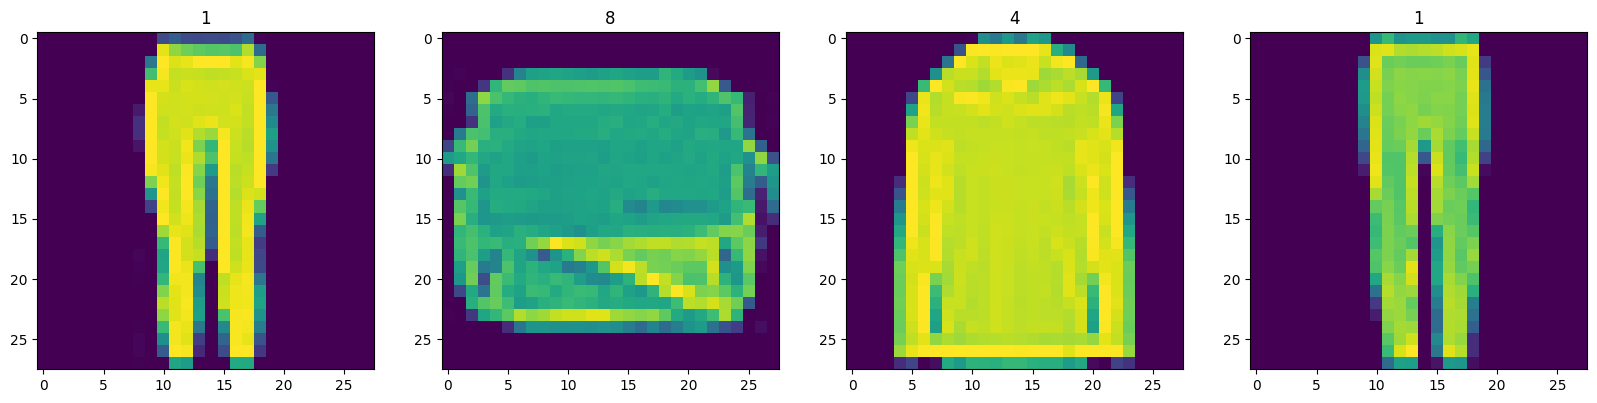

In [12]:
fig, ax =plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
  batch = data_iterator.next() #grab image and label
  ax[idx].imshow(np.squeeze(batch['image']))
  ax[idx].title.set_text(batch['label'])

In [13]:
#Scale and return images from "0 - 255" between "0-1" to build a better deep learning model
def scale_images(data):
  image = data['image']
  return image/255

In [14]:
#Steps to build datapipeline in tensorflow
ds = tfds.load('fashion_mnist', split='train') #reload the dataset
ds = ds.map(scale_images) #running the dataset through the scale_images preprocessing step
ds = ds.cache() #temporarily store preprocessed  data in memory to speed up training and inference
ds = ds.shuffle(60000)
ds = ds.batch(128) #batch into 128 image per sample
ds = ds.prefetch(64) #reduces the liklehood of bottlenecking

In [15]:
#Converts the TensorFlow dataset into NumPy arrays.
ds.as_numpy_iterator().next().shape

(128, 28, 28, 1)


**3. Build Neural Network**



Import Modelling Components

- A 2D convolutional layer used for feature extraction in image data.
- A fully connected layer where each neuron is connected to every neuron in the previous layer. Used for classification or regression tasks at the end of a model.


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten, Reshape, LeakyReLU, Dropout, UpSampling2D


**Biuld a Generator**

(7, 7, 128): The target shape for the output.
7: Height of the tensor.
7: Width of the tensor.
128: Number of channels (depth).
***The total number of elements in the input must match the total number of elements in the output after reshaping.***


-The Dense layer outputs a flat vector of size 6272.
The Reshape layer converts it into a shape of (7, 7, 128).



In [17]:
# I am passing a 128 values to generator to help it find what to generate from there
def build_generator():
  model= Sequential()
  model.add(Dense(7*7*128, input_dim=128)) #input or fullly connected layer
  model.add(LeakyReLU(0.2))
  model.add(Reshape((7,7,128)))

  #upsamplingblock1
  model.add(UpSampling2D())
  model.add(Conv2D(128,kernel_size=5,padding='same'))
  model.add(LeakyReLU(0.2))

  #upsamplingblock2
  model.add(UpSampling2D())
  model.add(Conv2D(128,kernel_size=5,padding='same'))
  model.add(LeakyReLU(0.2))

  #Downsamplingblock1
  model.add(Conv2D(128,kernel_size=4,padding='same'))
  model.add(LeakyReLU(0.2))

   #Downsamplingblock2
  model.add(Conv2D(128,kernel_size=4,padding='same'))
  model.add(LeakyReLU(0.2))

  #finalconvlayer to get one channel
  model.add(Conv2D(1,kernel_size=4,padding="same",activation='sigmoid'))


  return model

In [18]:
generator =build_generator()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
generator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6272)                │         809,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 14, 14, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
imge = generator.predict(np.random.randn(4,128,1))
imge

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


array([[[[0.504738  ],
         [0.5149118 ],
         [0.5089117 ],
         ...,
         [0.50294524],
         [0.50173557],
         [0.49962643]],

        [[0.49551833],
         [0.50976264],
         [0.5020632 ],
         ...,
         [0.5073622 ],
         [0.50410515],
         [0.5016638 ]],

        [[0.49998987],
         [0.50913465],
         [0.5063912 ],
         ...,
         [0.50912863],
         [0.5061592 ],
         [0.5001083 ]],

        ...,

        [[0.49836636],
         [0.5049905 ],
         [0.5006901 ],
         ...,
         [0.50423634],
         [0.50347817],
         [0.50126517]],

        [[0.4935195 ],
         [0.49879044],
         [0.50059223],
         ...,
         [0.50231296],
         [0.5015812 ],
         [0.50213385]],

        [[0.49582234],
         [0.49831247],
         [0.499106  ],
         ...,
         [0.5001697 ],
         [0.50184894],
         [0.5031478 ]]],


       [[[0.5093713 ],
         [0.50207424],
         [0.50

In [21]:
imge.shape

(4, 28, 28, 1)

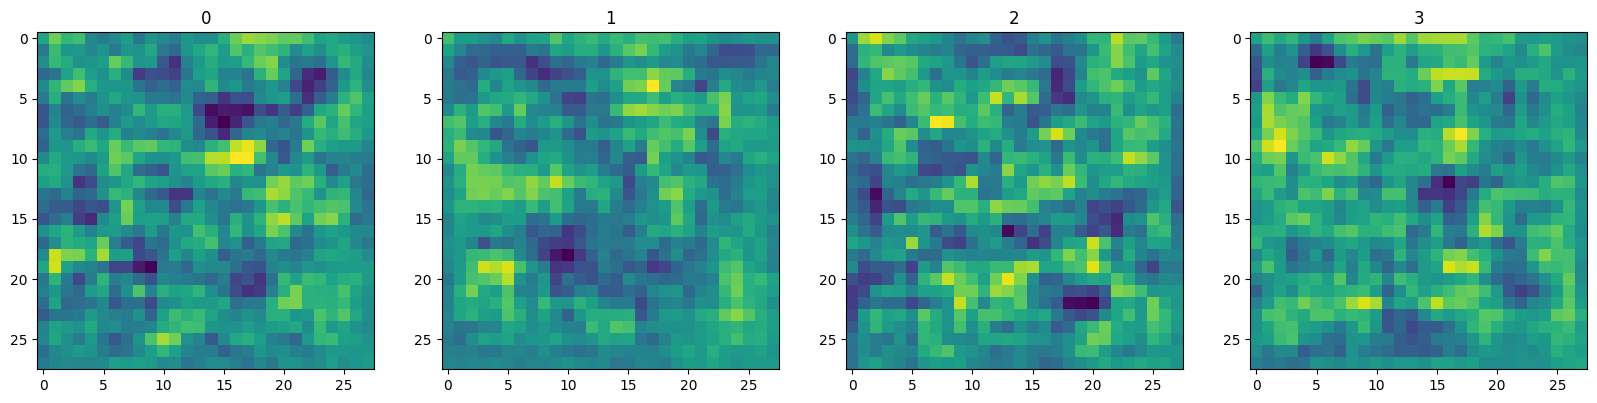

In [22]:
fig, ax =plt.subplots(ncols=4, figsize=(20,20))
for idx,img in enumerate(imge):
  ax[idx].imshow(np.squeeze(img))
  ax[idx].title.set_text(idx)

**Build Discrminator**

In [23]:
def build_discriminator():
  model= Sequential()

  #First convBlock
  model.add(Conv2D(32,5, input_shape=(28,28,1))) #32 filters in the shape of 5x5
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

  #Second convBlock
  model.add(Conv2D(64,5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

  #Third convBlock
  model.add(Conv2D(128,5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

  #Fourth convBlock
  model.add(Conv2D(256,5))
  model.add(LeakyReLU(0.2))
  model.add(Dropout(0.4))

  #Flatten--> pass to dropout
  model.add(Flatten())
  model.add(Dropout(0.4))
  model.add(Dense(1, activation='sigmoid')) #activation = sigmoid so the ouput value is between 0(true image) and 1(false image).
  return model


In [24]:
discriminator =build_discriminator()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
discriminator.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 24, 24, 32)          │             832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_5 (LeakyReLU)            │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 20, 20, 64)          │          51,264 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_6 (LeakyReLU)            │ (None, 20, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 20, 20, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 16, 16, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_7 (LeakyReLU)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 12, 12, 256)         │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_8 (LeakyReLU)            │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 36864)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          36,865 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,113,345 (4.25 MB)

 Trainable params: 1,113,345 (4.25 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
#imge=imge[0]

In [27]:
imge.shape

(4, 28, 28, 1)

In [28]:
#image_discriminator.predict(np.expand_dims(imge,0))

In [29]:
discriminator.predict(imge)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 656ms/step


array([[0.49860618],
       [0.4987034 ],
       [0.49874514],
       [0.49872592]], dtype=float32)

**Construct a Training Loop**





Setup Losses and Optimizers

In [30]:
from tensorflow.keras.optimizers import Adam #Adam for both gen n dis
from tensorflow.keras.losses import BinaryCrossentropy


In [31]:
g_opt = Adam(learning_rate=0.0001)
d_opt = Adam(learning_rate=0.00001)
g_loss= BinaryCrossentropy()
d_loss= BinaryCrossentropy()


Build Subclass Model

In [32]:
from tensorflow.keras.models import Model #importing base model class to subclass

In [33]:
tf.concat([tf.zeros_like(tf.random.normal((6,128))), tf.ones_like(tf.random.normal((6,128)))], axis=0)

<tf.Tensor: shape=(12, 128), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)>

In [34]:
class Fashion_GAN(Model):
  def __init__(self,generator, discriminator, *args, **kwargs):
    super().__init__(*args, **kwargs)
    self.generator=generator
    self.discriminator= discriminator

  def compile(self,g_opt,d_opt,g_loss,d_loss, *args, **kwargs):
    super().compile(*args, *kwargs)
    self.g_opt= g_opt
    self.d_opt=d_opt
    self.g_loss=g_loss
    self.d_loss=d_loss
    pass
  def train_step(self,batch):
    real_images=batch #get the data
    fake_images = self.generator(tf.random.normal((128,128,1)), training=False)

    #fake_images= self.generator(tf.random.randn((128,128,1)),training=False)

    # Train discriminator
    with tf.GradientTape() as d_tape:
      #pass real and fake images to discriminator
      ycap_real= self.discriminator(real_images, training= True)
      ycap_fake= self.discriminator(fake_images, training= False)
      ycap_realfake= tf.concat([ycap_real,ycap_fake], axis=0)

      #Create labels for real and fake images
      y_realfake =tf.concat([tf.zeros_like(ycap_real),tf.ones_like(ycap_fake)],axis=0) #128 0's and 128 1's

      #Add some noise to the outputs
      noise_real = 0.15*tf.random.uniform(tf.shape(ycap_real))
      noise_fake = -0.15*tf.random.uniform(tf.shape(ycap_fake))
      y_realfake += tf.concat([noise_real, noise_fake],axis=0)

      #calculate loss
      total_d_loss= self.d_loss(y_realfake, ycap_realfake)

    #Apply backpropagation -nn Learn
    dgrad=d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
    self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))

    #Train the Generator
    with tf.GradientTape() as g_tape:
      #Generator new images
      gen_images= self.generator(tf.random.normal((128,128,1),training= False))
      #create the predicted labels
      predicted_labels=self.discriminator(gen_images, training= False)
      #calculate loss
      total_g_loss=self.g_loss(tf.zeros_like(predicted_labels),predicted_labels)

    #Apply backpropgation
    ggrdad=g_tape.gradient(total_g_loss,self.generator.trainable_variables)
    self.g_opt.apply_gradients(zip(ggrad,self.generator.trainable_variables))

    return{"d_loss":total_d_loss,"g_loss": total_g_loss}




In [35]:
class FashionGAN(Model):
    def __init__(self, generator, discriminator, *args, **kwargs):
        # Pass through args and kwargs to base class
        super().__init__(*args, **kwargs)

        # Create attributes for gen and disc
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
        # Compile with base class
        super().compile(*args, **kwargs)

        # Create attributes for losses and optimizers
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss

    def train_step(self, batch):
        # Get the data
        real_images = batch
        fake_images = self.generator(tf.random.normal((128, 128, 1)), training=False)

        # Train the discriminator
        with tf.GradientTape() as d_tape:
            # Pass the real and fake images to the discriminator model
            yhat_real = self.discriminator(real_images, training=True)
            yhat_fake = self.discriminator(fake_images, training=True)
            yhat_realfake = tf.concat([yhat_real, yhat_fake], axis=0)

            # Create labels for real and fakes images
            y_realfake = tf.concat([tf.zeros_like(yhat_real), tf.ones_like(yhat_fake)], axis=0)

            # Add some noise to the TRUE outputs
            noise_real = 0.15*tf.random.uniform(tf.shape(yhat_real))
            noise_fake = -0.15*tf.random.uniform(tf.shape(yhat_fake))
            y_realfake += tf.concat([noise_real, noise_fake], axis=0)

            # Calculate loss - BINARYCROSS
            total_d_loss = self.d_loss(y_realfake, yhat_realfake)

        # Apply backpropagation - nn learn
        dgrad = d_tape.gradient(total_d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(dgrad, self.discriminator.trainable_variables))

        # Train the generator
        with tf.GradientTape() as g_tape:
            # Generate some new images
            gen_images = self.generator(tf.random.normal((128,128,1)), training=True)


            # Create the predicted labels
            predicted_labels = self.discriminator(gen_images, training=False)

            # Calculate loss - trick to training to fake out the discriminator
            total_g_loss = self.g_loss(tf.zeros_like(predicted_labels), predicted_labels)

        # Apply backprop
        ggrad = g_tape.gradient(total_g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(ggrad, self.generator.trainable_variables))

        return {"d_loss":total_d_loss, "g_loss":total_g_loss}

In [36]:
fashgan= FashionGAN(generator,discriminator)

In [37]:
fashgan.compile(g_opt,d_opt,g_loss,d_loss)

**Build a callback**

In [38]:
import os
from tensorflow.keras.preprocessing.image import array_to_img
from tensorflow.keras.callbacks import Callback

In [41]:
class ModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim

        # Create the 'images' directory if it doesn't exist
        os.makedirs('images', exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.uniform((self.num_img, self.latent_dim,1))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images.numpy()
        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('images', f'generated_img_{epoch}_{i}.png'))

**Train**

In [42]:
hist = fashgan.fit(ds, epochs=20, callbacks=[ModelMonitor()])

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - d_loss: 0.3864 - g_loss: 1.8358
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - d_loss: 0.2974 - g_loss: 6.5826
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - d_loss: 0.6259 - g_loss: 1.5519
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - d_loss: 0.6104 - g_loss: 0.6119
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 146ms/step - d_loss: 0.5449 - g_loss: 0.2188
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - d_loss: 0.3996 - g_loss: 0.0584
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 145ms/step - d_loss: 0.3372 - g_loss: 0.0114
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - d_loss: 0.3486 - g_loss: 0.0256
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - d_loss: 0.3384 - g_loss: 0.0292
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - d_loss: 0.3700 - g_loss: 0.0310
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 69s 146ms/step - d_loss: 0.7241 - g_loss: 0.4438
Epoch 12/20
469/469

**Chcek performance**

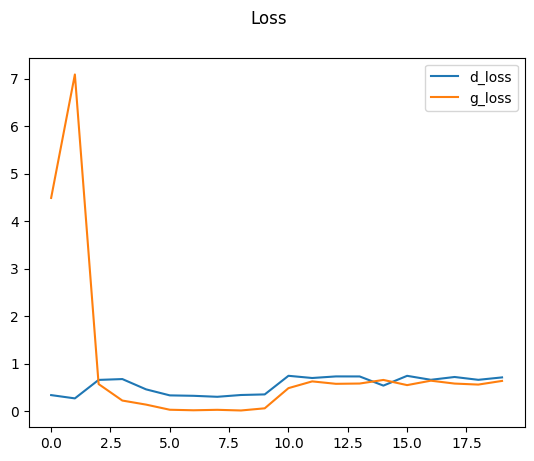

In [44]:
plt.suptitle('Loss')
plt.plot(hist.history['d_loss'], label='d_loss')
plt.plot(hist.history['g_loss'], label='g_loss')
plt.legend()
plt.show()

In [54]:
from google.colab import files
uploaded = files.upload()  # This will prompt you to upload the file


Saving generatormodel.h5 to generatormodel.h5


In [56]:
import shutil
shutil.move("generatormodel.h5", "archive/generatormodel.h5")
print("✅ File moved to archive folder!")


✅ File moved to archive folder!


In [58]:
import os

for root, dirs, files in os.walk("/"):
    for file in files:
        if file == "generatormodel.h5":
            print("✅ Found:", os.path.join(root, file))


✅ Found: /content/archive/generatormodel.h5


In [62]:
generator.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 6272)                │         809,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 14, 14, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 128)         │         409,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_3 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_4 (LeakyReLU)            │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │           2,049 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,155,137 (8.22 MB)

 Trainable params: 2,155,137 (8.22 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
latent_dim = 256  # Update based on the saved weights
generator = build_generator(latent_dim=latent_dim)


TypeError: build_generator() got an unexpected keyword argument 'latent_dim'

In [61]:
generator.load_weights("archive/generatormodel.h5")
print("✅ Weights loaded successfully!")


ValueError: Shape mismatch in layer #0 (named dense)for weight sequential/dense/kernel. Weight expects shape (128, 6272). Received saved weight with shape (1, 256)

In [50]:
imgs = generator.predict(tf.random.normal((16, 128, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


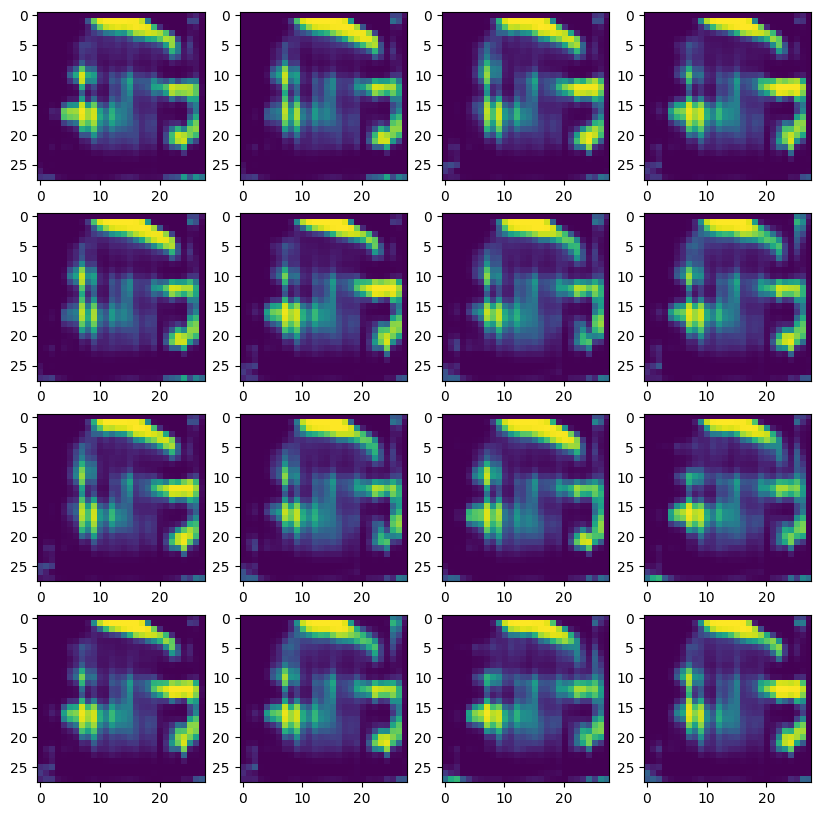

In [51]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
    for c in range(4):
        ax[r][c].imshow(imgs[(r+1)*(c+1)-1])